In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv('rounded_hours_student_scores.csv')

In [18]:
data.head(5)

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   60 non-null     float64
 1   Scores  60 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [20]:
data.describe()

,Hours,Scores
count,60.000000,60.000000
mean,5.150000,46.433333
std,2.402365,5.699737
min,1.100000,36.000000
25%,3.150000,41.000000
50%,5.150000,47.000000
75%,7.150000,50.000000
max,9.200000,65.000000


In [21]:
data.isna().sum()


Hours     0
Scores    0
dtype: int64

In [22]:
X = data[['Hours']]
y = data['Scores']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

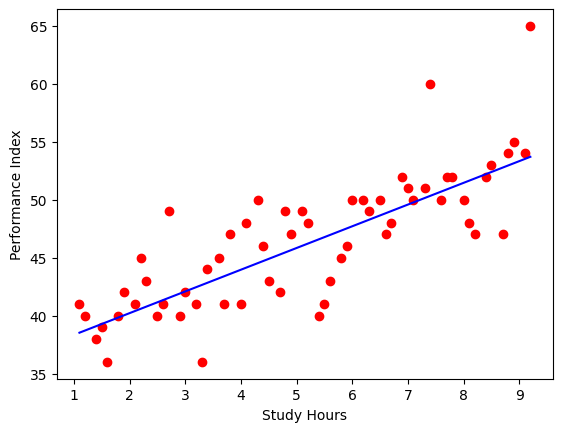

In [26]:
plt.scatter(X, y ,c='r')
plt.plot(X, model.predict(X),c='b')
plt.xlabel("Study Hours")
plt.ylabel("Performance Index")
plt.show()

In [27]:
new_h = pd.DataFrame([[6]], columns=['Hours'])
model.predict(new_h)

array([47.70626493])

In [28]:
data.corr()

,Hours,Scores
Hours,1.000000,0.798388
Scores,0.798388,1.000000
